# Tournament Simulation — Single Elite Cup

An Elite Cup tournament runs `n_cups` (10) Cups of the Week and applies the
**best-of-N** rule: each player's final score is the sum of their top `best_of` (5)
cup results.

This notebook runs **one** tournament and inspects the round-by-round results:
- Which cups counted for the top 16 finishers?
- How did three individual players fare cup-by-cup?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tmonacodel.config import TournamentConfig
from tmonacodel.player import make_player_pool
from tmonacodel.scoring import build_points_table, build_finish_position_lookup
from tmonacodel.cup import simulate_cup

sns.set_theme(style='whitegrid')

config = TournamentConfig(n_players=128, random_seed=42)
players = make_player_pool(config)
points_table = build_points_table(config.n_qualifiers)
finish_pos_lookup = build_finish_position_lookup(config)

print(f"Players:     {config.n_players}")
print(f"Cups:        {config.n_cups}")
print(f"Best-of:     {config.best_of}")
print(f"Qualifiers:  {config.n_qualifiers} per cup")

Players:     128
Cups:        10
Best-of:     5
Qualifiers:  64 per cup


## Run one tournament

We replicate `simulate_tournament` at one level lower so we can keep the full
`cup_points` matrix (shape `n_cups × n_players`) before the best-of reduction.

In [2]:
rng = np.random.default_rng(config.random_seed)

# cup_points[cup, player] = points earned by that player in that cup (0 = DNQ)
cup_points = np.empty((config.n_cups, config.n_players), dtype=np.int64)
for m in range(config.n_cups):
    cup_points[m] = simulate_cup(config, points_table, finish_pos_lookup, rng)

# Best-of-N per player: top `best_of` cup scores
player_cup = cup_points.T  # shape (n_players, n_cups)
sorted_desc = np.sort(player_cup, axis=1)[:, ::-1]
total_pts = sorted_desc[:, : config.best_of].sum(axis=1)

# Rank (1 = highest)
order = np.argsort(-total_pts, kind="stable")
ranks = np.empty(config.n_players, dtype=np.int64)
ranks[order] = np.arange(1, config.n_players + 1)

# Counting-cup mask: True where a cup score is among the top `best_of` for that player
counting = np.zeros((config.n_players, config.n_cups), dtype=bool)
for i in range(config.n_players):
    top_idx = np.argsort(player_cup[i])[::-1][: config.best_of]
    counting[i, top_idx] = True

print(f"Tournament complete.")
print(f"Winner: {players[order[0]].name}  ({total_pts[order[0]]} pts)")
print(f"Runner-up: {players[order[1]].name}  ({total_pts[order[1]]} pts)")

Tournament complete.
Winner: Generic_80  (2140 pts)
Runner-up: Generic_70  (1632 pts)


## Top 16 — round-by-round results

Each column is one cup. **Bold green** cells are the cups that count toward that
player's tournament total (their best `best_of` results). Grey cells were dropped.

In [3]:
cup_labels = [f"Cup {i+1}" for i in range(config.n_cups)]

# Build full dataframe for all players
df_all = pd.DataFrame(
    player_cup,
    columns=cup_labels,
)
df_all.insert(0, "Rank", ranks)
df_all.insert(1, "Name", [p.name for p in players])
df_all.insert(2, "Nation", [p.country if p.country else "—" for p in players])
df_all["Total"] = total_pts

df_top16 = df_all.sort_values("Rank").head(16).reset_index(drop=True)

# counting mask restricted to top-16 players (in rank order)
top16_player_ids = df_all.sort_values("Rank").head(16).index.tolist()
counting_top16 = counting[top16_player_ids]  # shape (16, n_cups)

def style_counting(df, mask, cup_cols):
    """Apply green highlight to counting cup cells."""
    style_df = pd.DataFrame("", index=df.index, columns=df.columns)
    for row_i, (_, row) in enumerate(df.iterrows()):
        for col_j, col in enumerate(cup_cols):
            if mask[row_i, col_j]:
                style_df.loc[row.name, col] = "background-color: #c6efce; font-weight: bold"
            else:
                style_df.loc[row.name, col] = "color: #999999"
    return style_df

styled = (
    df_top16.style
    .apply(lambda _: style_counting(df_top16, counting_top16, cup_labels), axis=None)
    .format({col: "{:,}" for col in cup_labels + ["Total"]})
    .set_caption(f"Top 16 — green = counts toward total (best {config.best_of} of {config.n_cups})")
)

styled

,Rank,Name,Nation,Cup 1,Cup 2,Cup 3,Cup 4,Cup 5,Cup 6,Cup 7,Cup 8,Cup 9,Cup 10,Total
0,1,Generic_80,—,56,"1,000","1,000",0,56,0,28,0,0,0,"2,140"
1,2,Generic_70,—,0,0,600,4,200,0,40,0,700,92,"1,632"
2,3,Generic_44,—,0,20,48,76,600,14,700,200,0,0,"1,624"
3,4,Generic_64,—,0,88,20,0,30,"1,000",300,6,0,0,"1,438"
4,5,Generic_46,—,96,10,200,0,30,4,22,30,"1,000",60,"1,386"
5,6,Generic_63,—,0,200,44,0,"1,000",24,0,0,14,88,"1,356"
6,7,Generic_19,—,0,14,56,0,400,40,48,92,48,700,"1,296"
7,8,Generic_36,—,44,22,20,0,0,100,0,"1,000",0,16,"1,186"
8,9,Generic_100,—,2,0,30,4,92,0,0,28,0,"1,000","1,154"
9,10,Generic_122,—,0,24,44,"1,000",0,40,0,0,0,0,"1,108"


## Three players in focus

Pick one player from near the top, one from the middle, and one from the bottom.
Same format as above — green = counting cup, grey = dropped.

In [4]:
# Choose players by approximate rank position
focus_ranks = [1, config.n_players // 2, config.n_players]
focus_ids = [order[r - 1] for r in focus_ranks]  # player indices

focus_rows = df_all[df_all.index.isin(focus_ids)].sort_values("Rank").reset_index(drop=True)
focus_player_ids = df_all[df_all.index.isin(focus_ids)].sort_values("Rank").index.tolist()
counting_focus = counting[focus_player_ids]

styled_focus = (
    focus_rows.style
    .apply(lambda _: style_counting(focus_rows, counting_focus, cup_labels), axis=None)
    .format({col: "{:,}" for col in cup_labels + ["Total"]})
    .set_caption(f"Focus players — green = counts toward total (best {config.best_of} of {config.n_cups})")
)

styled_focus

,Rank,Name,Nation,Cup 1,Cup 2,Cup 3,Cup 4,Cup 5,Cup 6,Cup 7,Cup 8,Cup 9,Cup 10,Total
0,1,Generic_80,—,56,"1,000","1,000",0,56,0,28,0,0,0,"2,140"
1,64,Generic_109,—,22,0,24,0,0,80,84,0,0,36,246
2,128,Generic_110,—,0,0,0,0,0,8,0,4,36,0,48


## Points distribution across cups

For the three focus players, plot their cup-by-cup scores as a bar chart.
Counting cups are shown in green; dropped cups in grey.

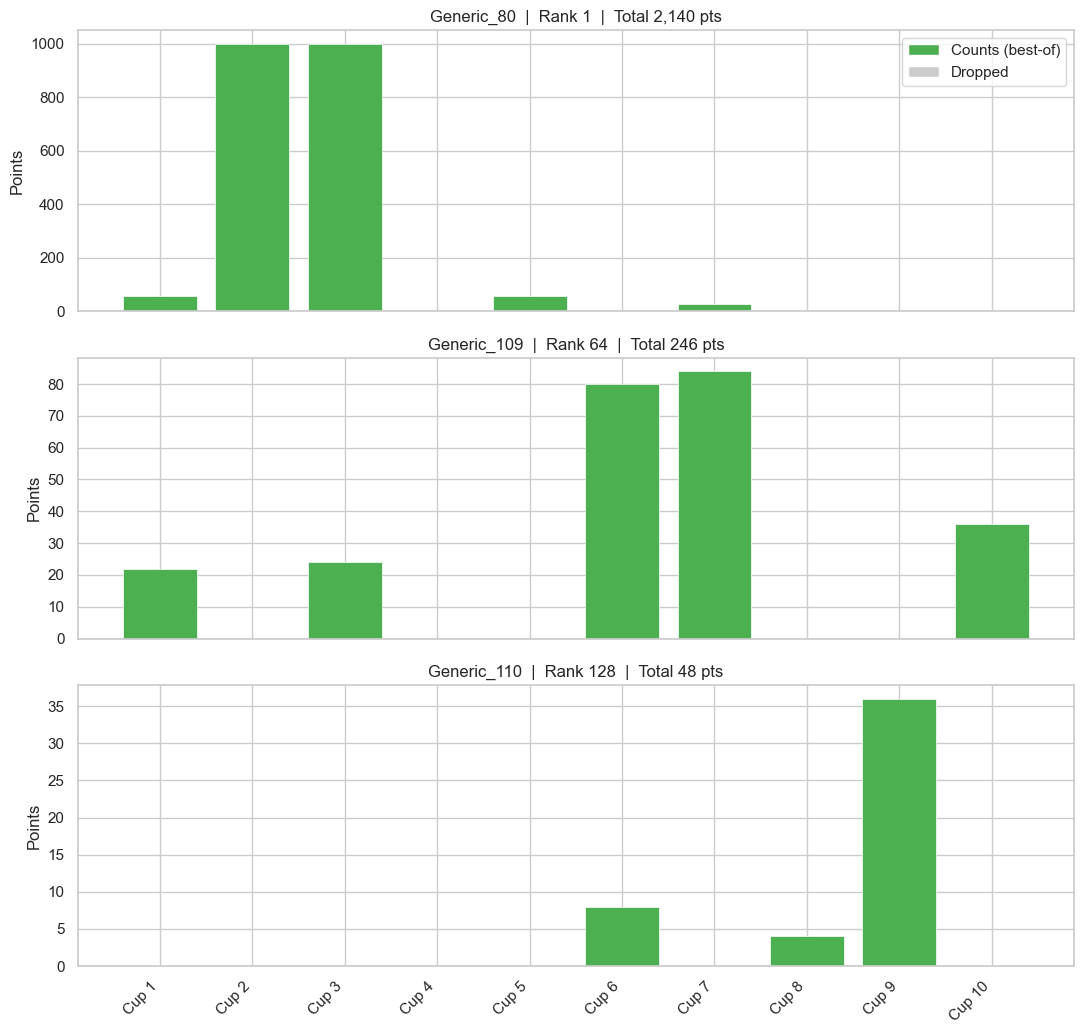

In [5]:
fig, axes = plt.subplots(len(focus_ids), 1, figsize=(11, 3.5 * len(focus_ids)), sharex=True)

x = np.arange(config.n_cups)

for ax, pid, mask_row in zip(axes, focus_player_ids, counting_focus):
    scores = player_cup[pid]
    colors = ["#4caf50" if m else "#cccccc" for m in mask_row]
    ax.bar(x, scores, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_ylabel("Points")
    ax.set_title(
        f"{players[pid].name}  |  "
        f"Rank {ranks[pid]}  |  "
        f"Total {total_pts[pid]:,} pts"
    )
    ax.set_xticks(x)
    ax.set_xticklabels(cup_labels, rotation=45, ha="right")
    ax.axhline(0, color="black", linewidth=0.5)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4caf50", label="Counts (best-of)"),
    Patch(facecolor="#cccccc", label="Dropped"),
]
axes[0].legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.show()

## Partial tournament mode

When some cups have already happened, pass `real_cup_results` to `run_monte_carlo`.
Each entry is either a `dict[player_name → points]` (a real cup) or `None` (simulate it).
The fixed cups are identical across all simulations; only the `None` slots are randomised.

In [6]:
from tmonacodel import run_monte_carlo, TournamentConfig, REAL_PLAYERS

# Simulate the full tournament (no real results)
cfg = TournamentConfig(n_simulations=1_000, random_seed=42)
full_results = run_monte_carlo(cfg, player_data=REAL_PLAYERS)

# 3 cups have already happened; 7 remain to be simulated.
# Points below are illustrative — replace with actual cup standings.
real_cup_results = [
    {"Mudda": 1000, "Binkss": 700, "Massa": 600, "GranaDy": 500, "Carl Jr.": 400},
    {"Binkss": 1000, "Wosile": 700, "Bren": 600, "Mudda": 500, "Nayko": 400},
    {"Massa": 1000, "Mudda": 700, "Carl Jr.": 600, "Binkss": 500, "GranaDy": 400},
    None, None, None, None, None, None, None,  # 7 cups still to play
]

partial_results = run_monte_carlo(
    cfg, player_data=REAL_PLAYERS, real_cup_results=real_cup_results
)

full_df = full_results.summary_dataframe().set_index("name")[["mean_rank", "prob_top_N"]]
partial_df = partial_results.summary_dataframe().set_index("name")[["mean_rank", "prob_top_N"]]

comparison = full_df.join(partial_df, lsuffix="_full", rsuffix="_partial")
comparison.columns = ["mean_rank_full", "prob_top_N_full", "mean_rank_partial", "prob_top_N_partial"]
comparison = comparison.sort_values("mean_rank_partial")

print("Top 10 — fully simulated vs. partial (3 real cups + 7 simulated):")
print(comparison.head(10).to_string(float_format="{:.3f}".format))

Top 10 — fully simulated vs. partial (3 real cups + 7 simulated):
              mean_rank_full  prob_top_N_full  mean_rank_partial  prob_top_N_partial
name                                                                                
Mudda                 62.770            0.136              1.763               1.000
Binkss                64.347            0.122              1.771               1.000
Massa                 64.667            0.128              3.049               1.000
Carl Jr.              64.844            0.119              8.914               0.991
GranaDy               63.683            0.140             11.382               0.943
Wosile                65.299            0.137             12.035               0.713
Bren                  63.600            0.122             16.260               0.431
Nayko                 63.819            0.140             30.040               0.155
Goldennugg3t          63.745            0.123             65.736               0.101